# BNS vs BHNS: GRB Population Comparison

Side-by-side comparison of GRB class fractions and formation efficiencies for Binary Neutron Stars (BNS) and Black Hole – Neutron Star (BHNS) mergers.

Uses results from `GRB_BNS.ipynb` (Model A, fiducial) and `GRB_BHNS.ipynb` (Model A, BH spin a=0.5).

Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first to generate the `.npy` export files, or run those notebooks to have the variables in memory.

## 1. Load Saved Efficiency Arrays

In [1]:
import numpy as np
import matplotlib.pyplot as plt

metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

bns  = np.load('/Users/josephrodriguez/research visualization/results/eff_BNS.npy')
bhns = np.load('/Users/josephrodriguez/research visualization/results/eff_BHNS.npy')

eff_total_BNS,  eff_short_BNS,  eff_long_BNS                      = bns
eff_total_BHNS, eff_short_BHNS_a05, eff_long_BHNS_a05, eff_nogrb_BHNS = bhns

print('BNS  - total efficiency range:',
      f'{eff_total_BNS[eff_total_BNS>0].min():.2e} – {eff_total_BNS.max():.2e}')
print('BHNS - total efficiency range:',
      f'{eff_total_BHNS[eff_total_BHNS>0].min():.2e} – {eff_total_BHNS.max():.2e}')

BNS  - total efficiency range: 4.79e-07 – 4.37e-06
BHNS - total efficiency range: 3.95e-10 – 1.21e-05


## 2. GRB Class Fractions: BNS vs BHNS

Fraction of all merging systems in each GRB class. BHNS fractions are for assumed BH spin `a = 0.5`.

**Assumptions:**
- **BNS:** Gottlieb et al. (2023) [arXiv:2309.00038] with $M_{\rm crit} = 2.8\,M_\odot$, $q_{\rm thresh} = 1.2$. 100% GRB efficiency -- all BNS mergers produce either a short or long cbGRB. No SMNS/stable-NS category.
- **BHNS:** Foucart et al. (2018) [arXiv:1807.00011] Eq. (4) with all four fitted parameters $(\alpha,\beta,\gamma,\delta) = (0.406, 0.139, 0.255, 1.761)$. Single NS radius $R_{\rm NS} = 11\,\mathrm{km}$ for all systems. BH spin is not tracked by COMPAS; fractions are conditional on the assumed value.

In [2]:
import h5py

# ── BNS: load & classify (Gottlieb M_crit=2.8, q_thresh=1.2) ─────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _m1_bns = _d['M1'][...].squeeze()
    _m2_bns = _d['M2'][...].squeeze()
    _mg_bns = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _w_bns  = _d['weight'][...].squeeze()

_mask_bns = (_mg_bns == 1)
_Mtot_bns = _m1_bns[_mask_bns] + _m2_bns[_mask_bns]
_q_bns    = (np.maximum(_m1_bns[_mask_bns], _m2_bns[_mask_bns]) /
             np.minimum(_m1_bns[_mask_bns], _m2_bns[_mask_bns]))
_wb_bns   = _w_bns[_mask_bns]
_W_bns    = _wb_bns.sum()

_short_bns = ((_Mtot_bns < 2.8) | ((_Mtot_bns >= 2.8) & (_q_bns < 1.2)))
_long_bns  = ((_Mtot_bns >= 2.8) & (_q_bns >= 1.2))

bns_frac = [
    100 * _wb_bns[_short_bns].sum() / _W_bns,  # Short cbGRB (weighted)
    100 * _wb_bns[_long_bns].sum()  / _W_bns,  # Long cbGRB (weighted)
    0.0,                                         # No GRB (BNS always produces a remnant)
]

# ── BHNS: load & classify (Foucart et al. 2018, a=0.5) ───────────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _M1       = _d['M1'][...].squeeze()
    _M2       = _d['M2'][...].squeeze()
    _mg_bhns  = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _stype1   = _d['stellarType1'][...].squeeze()
    _w_bhns   = _d['weight'][...].squeeze()

_isBH = (_stype1 == 14)
assert np.all((_stype1 == 14) | (_stype1 == 13)), \
    "Unexpected stellar type in BHNS file — expected only types 13 (NS) and 14 (BH)"
assert _isBH[_mg_bhns == 1].any() and (~_isBH[_mg_bhns == 1]).any(), \
    "BH/NS assignment error: all merging systems have the same stellar type"
_BH   = np.where(_isBH, _M1, _M2)
_NS   = np.where(_isBH, _M2, _M1)
_mask_bhns = (_mg_bhns == 1)
_BH_m, _NS_m = _BH[_mask_bhns], _NS[_mask_bhns]
_wb_bhns = _w_bhns[_mask_bhns]
_W_bhns  = _wb_bhns.sum()

def _foucart_disk(MBH, MNS, a=0.5, R_km=11.0):
    """Foucart et al. (2018) [arXiv:1807.00011] Eq. (4) & (6)."""
    G=6.674e-11; c=3e8; Ms=1.989e30
    qr = MNS/MBH
    fr = 0.49*qr**(2/3)/(0.6*qr**(2/3)+np.log(1+qr**(1/3)))
    Z1 = 1+(1-a**2)**(1/3)*((1+a)**(1/3)+(1-a)**(1/3))
    Z2 = np.sqrt(3*a**2+Z1**2)
    sign = np.where(a >= 0, 1.0, -1.0)
    ri = 3+Z2-sign*np.sqrt((3-Z1)*(3+Z1+2*Z2))
    rt = (R_km*1e3)/fr
    rI = ri*G*MBH*Ms/c**2
    C  = G*MNS*Ms/(R_km*1e3*c**2)
    eta= MNS*MBH/(MNS+MBH)**2
    R_hat = ri                                               # R_ISCO/M_BH [dimensionless]
    alpha, beta, gamma, delta = 0.406, 0.139, 0.255, 1.761
    Md = np.maximum(0., alpha*(1-2*C)/eta**(1/3)-beta*R_hat*C/eta+gamma)**delta*MNS
    return np.where(rt > rI, Md, 0.0)

_disk05  = _foucart_disk(_BH_m, _NS_m, a=0.5)
_disk07  = _foucart_disk(_BH_m, _NS_m, a=0.7)  # for spin sensitivity note

bhns_frac = [
    100 * _wb_bhns[(_disk05 >= 0.01) & (_disk05 < 0.1)].sum() / _W_bhns,  # Short cbGRB (weighted)
    100 * _wb_bhns[_disk05 >= 0.1].sum()                      / _W_bhns,  # Long cbGRB (weighted)
    100 * _wb_bhns[_disk05 < 0.01].sum()                      / _W_bhns,  # No GRB (weighted)
]

# Spin sensitivity values for annotation (weighted)
_nogrb07 = 100 * _wb_bhns[_disk07 < 0.01].sum()  / _W_bhns
_long07  = 100 * _wb_bhns[_disk07 >= 0.1].sum()  / _W_bhns

print(f"BNS  — Short: {bns_frac[0]:.1f}%  Long: {bns_frac[1]:.1f}%  No GRB: {bns_frac[2]:.1f}%")
print(f"BHNS — Short: {bhns_frac[0]:.1f}%  Long: {bhns_frac[1]:.1f}%  No GRB: {bhns_frac[2]:.1f}%")
print(f"BHNS a=0.7  — No GRB: {_nogrb07:.1f}%  Long: {_long07:.1f}%")

BNS  — Short: 74.6%  Long: 25.4%  No GRB: 0.0%
BHNS — Short: 8.3%  Long: 0.0%  No GRB: 91.7%
BHNS a=0.7  — No GRB: 79.2%  Long: 5.9%


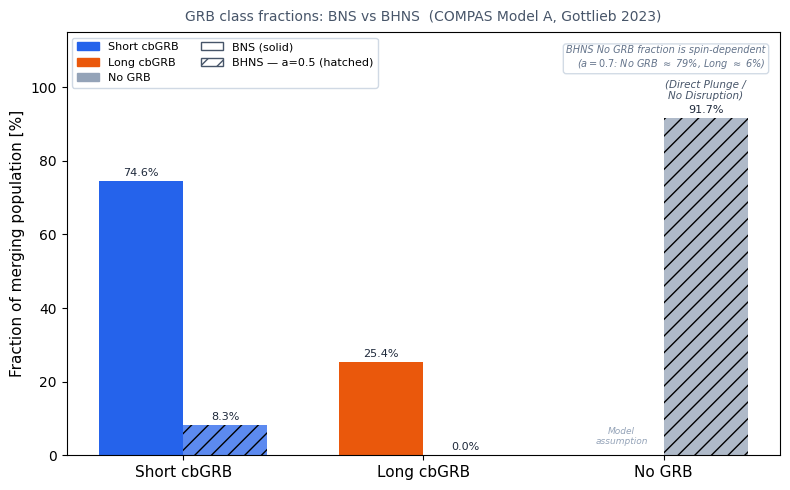

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['Short cbGRB', 'Long cbGRB', 'No GRB']
# bns_frac and bhns_frac computed dynamically in the cell above
colors    = ['#2563EB', '#EA580C', '#94A3B8']

x = np.arange(len(labels))
w = 0.35

bars_bns  = ax.bar(x - w/2, bns_frac,  w, color=colors)
bars_bhns = ax.bar(x + w/2, bhns_frac, w, color=colors, alpha=0.75,
                   hatch='//')

# Quantitative labels above bars — skip 0% entirely (absent bar already communicates it)
for bar in bars_bns:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#1E293B')

for bar in bars_bhns:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#1E293B')

# 'Direct Plunge' annotation — position driven by computed bhns_frac[2]
ax.text(x[2] + w/2, bhns_frac[2] + 4.5,
        '(Direct Plunge /\nNo Disruption)', ha='center', va='bottom',
        fontsize=7.5, color='#475569', style='italic')

# BNS No GRB = 0% is a model assumption (Gottlieb criterion), not a physical law
ax.text(x[2] - w/2, 2.5,
        'Model\nassumption', ha='center', va='bottom',
        fontsize=6.5, color='#94A3B8', style='italic')

ax.set_title('GRB class fractions: BNS vs BHNS  (COMPAS Model A, Gottlieb 2023)',
             fontsize=10, color='#475569', pad=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Fraction of merging population [%]', fontsize=11)
ax.set_ylim(0, 115)

# Manual legend: color = GRB category, pattern = population
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2563EB', edgecolor='#2563EB', label='Short cbGRB'),
    Patch(facecolor='#EA580C', edgecolor='#EA580C', label='Long cbGRB'),
    Patch(facecolor='#94A3B8', edgecolor='#94A3B8', label='No GRB'),
    Patch(facecolor='white',   edgecolor='#475569', label='BNS (solid)'),
    Patch(facecolor='white',   edgecolor='#475569', hatch='//',
          label='BHNS — a=0.5 (hatched)'),
]
ax.legend(handles=legend_elements, fontsize=8, framealpha=0.9,
          edgecolor='#CBD5E1', ncol=2, loc='upper left')

# Spin sensitivity note — values computed dynamically
ax.text(0.98, 0.97,
        f'BHNS No GRB fraction is spin-dependent\n'
        f'($a=0.7$: No GRB $\\approx$ {_nogrb07:.0f}%, Long $\\approx$ {_long07:.0f}%)',
        transform=ax.transAxes, fontsize=7, color='#64748B',
        ha='right', va='top', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#CBD5E1', alpha=0.85))
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/comparison_grb_fractions.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 3. Formation Efficiency vs Metallicity

BNS (blue) and BHNS (orange) formation efficiency per solar mass of star-forming material, broken down by GRB class.

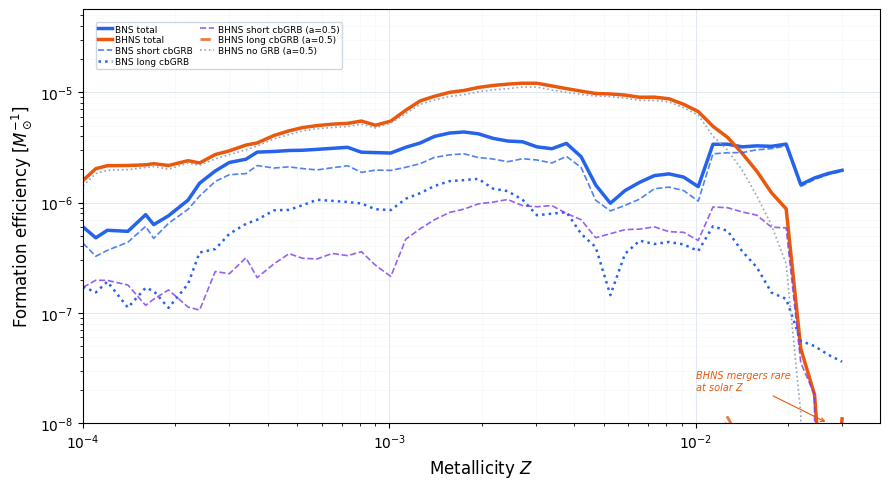

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

# Total lines — heroes of the plot (lw=2.5)
ax.plot(metallicityGrid, eff_total_BNS,    color='#2563EB', lw=2.5,
        label='BNS total')
ax.plot(metallicityGrid, eff_total_BHNS,   color='#EA580C', lw=2.5,
        label='BHNS total')

# Sub-population lines — supporting detail (lw=1.2, alpha=0.8)
ax.plot(metallicityGrid, eff_short_BNS,     color='#2563EB', lw=1.2, ls='--',
        alpha=0.8, label='BNS short cbGRB')
ax.plot(metallicityGrid, eff_long_BNS,      color='#2563EB', lw=1.8, ls=':',
        alpha=1.0, label='BNS long cbGRB')
ax.plot(metallicityGrid, eff_short_BHNS_a05, color='#7C3AED', lw=1.2, ls='--',
        alpha=0.8, label='BHNS short cbGRB (a=0.5)')
ax.plot(metallicityGrid, eff_long_BHNS_a05,  color='#EA580C', lw=2.0, ls='--',
        alpha=0.8, label='BHNS long cbGRB (a=0.5)')
ax.plot(metallicityGrid, eff_nogrb_BHNS,     color='#94A3B8', lw=1.2, ls=':',
        alpha=1.0, label='BHNS no GRB (a=0.5)')

# Subtle grid — major and minor ticks
ax.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-')
ax.grid(which='minor', color='#F1F5F9', linewidth=0.4, linestyle='-')
ax.set_axisbelow(True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.margins(y=0.15)
ax.set_ylim(bottom=1e-8)
ax.set_xlim(left=1e-4)
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
ax.legend(fontsize=6.5, ncol=2, framealpha=0.95, edgecolor='#CBD5E1',
          loc='upper left', bbox_to_anchor=(0.01, 0.98),
          borderpad=0.3, labelspacing=0.2,
          handlelength=1.5, handletextpad=0.4,
          columnspacing=0.8)
# Annotate the sharp BHNS drop at high Z
ax.annotate('BHNS mergers rare\nat solar Z',
            xy=(0.027, 1e-8), xytext=(0.010, 0.2e-7),
            fontsize=7, color='#EA580C', style='italic',
            arrowprops=dict(arrowstyle='->', color='#EA580C',
                           lw=0.8))
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/comparison_efficiency.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 4. Metallicity vs Delay Time

Scatter plot of progenitor metallicity versus total delay time (t_form + t_c)
for each GRB / merger class in both BNS and BHNS populations.
Delay time = time from star formation to merger.

> **Note on jitter:** Metallicity values in COMPAS output sit on a discrete grid of 53 points.
> To prevent overplotting on this grid, each point's metallicity is multiplied by
> 10^U where U ~ Uniform(−0.04, 0.04) — a ±4% perturbation in log10(Z).
> This is purely cosmetic and does not affect any computed quantities.

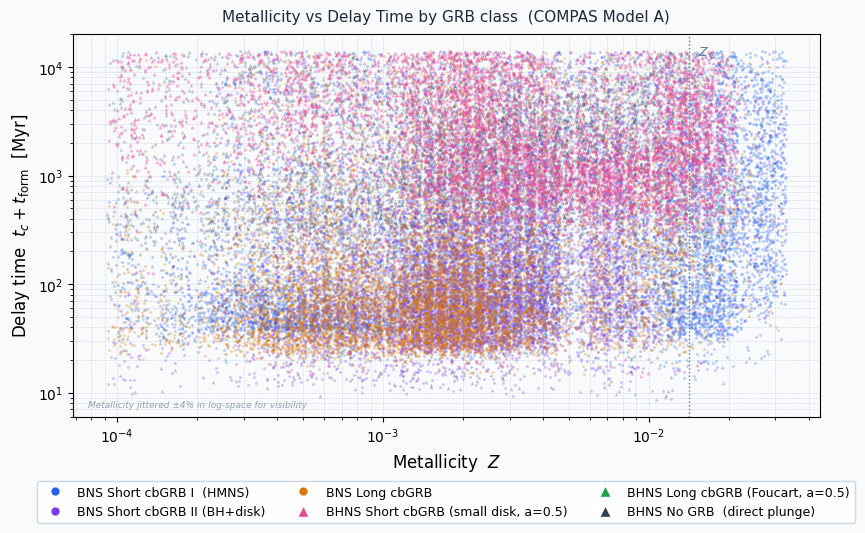

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Load BNS raw data ─────────────────────────────────────────────────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _bns_m1   = _d['M1'][...].squeeze()
    _bns_m2   = _d['M2'][...].squeeze()
    _bns_mg   = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _bns_Z    = _d['Metallicity1'][...].squeeze()
    _bns_tc   = _d['tc'][...].squeeze()
    _bns_tform= _d['tform'][...].squeeze()
    _bns_w    = _d['weight'][...].squeeze()

_bmask      = (_bns_mg == 1)
_bns_Mtot   = (_bns_m1 + _bns_m2)[_bmask]
_bns_q      = (np.maximum(_bns_m1, _bns_m2) / np.minimum(_bns_m1, _bns_m2))[_bmask]
_bns_delay  = (_bns_tc + _bns_tform)[_bmask]       # Myr
_bns_Zval   = _bns_Z[_bmask]
_bns_weight = _bns_w[_bmask]

# Gottlieb classification
_bns_shortI  = (_bns_Mtot < 2.8)
_bns_shortII = (_bns_Mtot >= 2.8) & (_bns_q < 1.2)
_bns_long    = (_bns_Mtot >= 2.8) & (_bns_q >= 1.2)

# ── Load BHNS raw data ────────────────────────────────────────────────────────
with h5py.File('/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5', 'r') as f:
    _d = f['doubleCompactObjects']
    _bh_m1    = _d['M1'][...].squeeze()
    _bh_m2    = _d['M2'][...].squeeze()
    _bh_mg    = _d['mergesInHubbleTimeFlag'][...].squeeze()
    _bh_stype = _d['stellarType1'][...].squeeze()
    _bh_Z     = _d['Metallicity1'][...].squeeze()
    _bh_tc    = _d['tc'][...].squeeze()
    _bh_tform = _d['tform'][...].squeeze()
    _bh_w     = _d['weight'][...].squeeze()

_hhmask    = (_bh_mg == 1)
_isBH      = (_bh_stype == 14)
# Sanity-check: every row must be either BH (14) or NS (13)
assert np.all((_bh_stype == 14) | (_bh_stype == 13)), \
    "Unexpected stellar type in BHNS file — expected only types 13 (NS) and 14 (BH)"
assert _isBH[_hhmask].any() and (~_isBH[_hhmask]).any(), \
    "BH/NS assignment error: all systems have the same stellar type"
_BH_m      = np.where(_isBH, _bh_m1, _bh_m2)[_hhmask]
_NS_m      = np.where(_isBH, _bh_m2, _bh_m1)[_hhmask]
_bh_delay  = (_bh_tc + _bh_tform)[_hhmask]         # Myr
_bh_Zval   = _bh_Z[_hhmask]
_bh_weight = _bh_w[_hhmask]

# Foucart et al. (2018) [arXiv:1807.00011] disk mass (a=0.5), Eq. (4) & (6)
def _foucart_disk_v2(MBH, MNS, a=0.5, R_km=11.0):
    G = 6.674e-11; c = 3e8; Ms = 1.989e30
    qr  = MNS / MBH
    fr  = 0.49 * qr**(2/3) / (0.6 * qr**(2/3) + np.log(1 + qr**(1/3)))
    Z1  = 1 + (1-a**2)**(1/3) * ((1+a)**(1/3) + (1-a)**(1/3))
    Z2  = np.sqrt(3*a**2 + Z1**2)
    sign = np.where(a >= 0, 1.0, -1.0)
    ri  = 3 + Z2 - sign * np.sqrt((3-Z1)*(3+Z1+2*Z2))
    rI  = ri * G * MBH * Ms / c**2
    rt  = (R_km * 1e3) / fr
    C   = G * MNS * Ms / (R_km * 1e3 * c**2)
    eta = MNS * MBH / (MNS + MBH)**2
    R_hat = ri                                               # R_ISCO/M_BH [dimensionless]
    alpha, beta, gamma, delta = 0.406, 0.139, 0.255, 1.761
    Md  = np.maximum(0., alpha*(1-2*C)/eta**(1/3) - beta*R_hat*C/eta + gamma)**delta * MNS
    return np.where(rt > rI, Md, 0.0)

_disk = _foucart_disk_v2(_BH_m, _NS_m, a=0.5)
_bh_short = (_disk >= 0.01) & (_disk < 0.1)
_bh_long  = (_disk >= 0.1)
_bh_nogrb = (_disk < 0.01)

# ── Downsample for readability ────────────────────────────────────────────────
rng = np.random.default_rng(42)

def weighted_sample(mask, weight, n_target=12000):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return idx
    w = weight[idx]
    if w.sum() == 0:
        return idx[:min(n_target, len(idx))]   # fall back to unweighted if all weights are zero
    w = w / w.sum()
    n = min(n_target, len(idx))
    return rng.choice(idx, size=n, replace=False, p=w)

_s_shortI    = weighted_sample(_bns_shortI,  _bns_weight, 10000)
_s_shortII   = weighted_sample(_bns_shortII, _bns_weight, 10000)
_s_long_bns  = weighted_sample(_bns_long,    _bns_weight, 10000)
_s_bh_short  = weighted_sample(_bh_short,    _bh_weight,  6000)
_s_bh_long   = weighted_sample(_bh_long,     _bh_weight,  6000)
_s_bh_nogrb  = weighted_sample(_bh_nogrb,    _bh_weight,  6000)

# ── Log-space jitter to break discrete metallicity grid stripes ───────────────
_jitter_scale = 0.04   # ±4% in log10(Z)

def log_jitter(Z, scale=_jitter_scale):
    return Z * 10 ** rng.uniform(-scale, scale, size=len(Z))

_jZ_shortI    = log_jitter(_bns_Zval[_s_shortI])
_jZ_shortII   = log_jitter(_bns_Zval[_s_shortII])
_jZ_long_bns  = log_jitter(_bns_Zval[_s_long_bns])
_jZ_bh_short  = log_jitter(_bh_Zval[_s_bh_short])
_jZ_bh_long   = log_jitter(_bh_Zval[_s_bh_long])
_jZ_bh_nogrb  = log_jitter(_bh_Zval[_s_bh_nogrb])

# ── Color palette — perceptually distinct across all 5 classes ────────────────
C_shortI   = '#2563EB'  # vivid blue    — BNS Short cbGRB I  (HMNS)
C_shortII  = '#7C3AED'  # purple        — BNS Short cbGRB II (BH+disk)
C_bns_long = '#D97706'  # amber         — BNS Long cbGRB
C_bh_short = '#EC4899'  # pink          — BHNS Short cbGRB (small disk)
C_bh_long  = '#16A34A'  # green         — BHNS Long cbGRB (Foucart)
C_nogrb    = '#334155'  # dark slate    — BHNS No GRB (direct plunge)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#F8FAFC')

# BHNS No GRB first (bottom) — darker color + higher alpha so it's clearly visible
ax.scatter(_jZ_bh_nogrb, _bh_delay[_s_bh_nogrb],
           c=C_nogrb, s=7, alpha=0.28, linewidths=0,
           rasterized=True, marker='^', zorder=1)

kw_bns = dict(s=4, alpha=0.32, linewidths=0, rasterized=True, marker='o', zorder=3)
ax.scatter(_jZ_shortI,   _bns_delay[_s_shortI],   c=C_shortI,   **kw_bns)
ax.scatter(_jZ_shortII,  _bns_delay[_s_shortII],  c=C_shortII,  **kw_bns)
ax.scatter(_jZ_long_bns, _bns_delay[_s_long_bns], c=C_bns_long, **kw_bns)

# BHNS Short above no-GRB layer
ax.scatter(_jZ_bh_short, _bh_delay[_s_bh_short],
           c=C_bh_short, s=7, alpha=0.45, linewidths=0,
           rasterized=True, marker='^', zorder=3)

# BHNS Long on top
ax.scatter(_jZ_bh_long, _bh_delay[_s_bh_long],
           c=C_bh_long, s=7, alpha=0.35, linewidths=0,
           rasterized=True, marker='^', zorder=4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity  $Z$', fontsize=12)
ax.set_ylabel(r'Delay time  $t_c + t_\mathrm{form}$  [Myr]', fontsize=12)
ax.set_title('Metallicity vs Delay Time by GRB class  (COMPAS Model A)',
             fontsize=11, color='#1E293B', pad=9)

ax.grid(True, which='both', color='#CBD5E1', linewidth=0.4, linestyle='--', zorder=0)
ax.tick_params(labelsize=10)

ax.text(0.02, 0.02, f'Metallicity jittered ±{_jitter_scale*100:.0f}% in log-space for visibility',
        transform=ax.transAxes, fontsize=6.5, color='#94A3B8', ha='left', va='bottom',
        style='italic')

# Solar metallicity reference line — use blended transform so label is always near the top
from matplotlib.transforms import blended_transform_factory as _btf
_trans_x_data = _btf(ax.transData, ax.transAxes)
ax.axvline(0.0142, color='#64748B', lw=1.0, ls=':', zorder=2)
ax.text(0.0142 * 1.08, 0.97, r'$Z_\odot$',
        fontsize=9, color='#64748B', va='top', ha='left', transform=_trans_x_data)


# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_shortI,   markersize=7, label='BNS Short cbGRB I  (HMNS)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_shortII,  markersize=7, label='BNS Short cbGRB II (BH+disk)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_bns_long, markersize=7, label='BNS Long cbGRB'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor=C_bh_short, markersize=8, label='BHNS Short cbGRB (small disk, a=0.5)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor=C_bh_long,  markersize=8, label='BHNS Long cbGRB (Foucart, a=0.5)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor=C_nogrb,    markersize=8, label='BHNS No GRB  (direct plunge)'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.92,
          edgecolor='#CBD5E1', loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/metallicity_vs_delaytime.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()